In [ ]:
# Model
import os
from typing import Any

from langchain_core.callbacks import BaseCallbackHandler
from langchain_core.outputs import LLMResult
from langchain_ollama import ChatOllama

OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")


class TokenCountsCallbackHandler(BaseCallbackHandler):
    def on_llm_end(self, response: LLMResult, **_: Any) -> None:
        for generations in response.generations:
            for generation in generations:
                message = getattr(generation, "message", None)
                if message is not None:
                    meta = getattr(message, "usage_metadata", None)
                    if meta:
                        print(
                            f"🪙 Tokens input: {meta.get('input_tokens', 'N/A')}, "
                            f"Tokens output: {meta.get('output_tokens', 'N/A')}, "
                            f"Tokens total: {meta.get('total_tokens', 'N/A')}"
                        )


token_counts_callback_handler = TokenCountsCallbackHandler()


def make_llm(temperature: float) -> ChatOllama:
    return ChatOllama(
        base_url=OLLAMA_HOST,
        keep_alive="12m",
        model="qwen3.5:0.8b",
        temperature=temperature,
        reasoning=False,
        callbacks=[token_counts_callback_handler],
    )


llm_validator = make_llm(temperature=0.06)
llm_analytical = make_llm(temperature=0.12)
llm_generative = make_llm(temperature=0.24)
llm_creative = make_llm(temperature=0.48)

hello_world = llm_creative.invoke("Hello, world!")
hello_world.pretty_print()

🪙 Tokens input: 16, Tokens output: 10, Tokens total: 26
================================== Ai Message ==================================

Hello! How can I help you today?


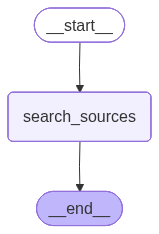

In [2]:
# Search Sources
import os
from typing import NotRequired, TypedDict

import trafilatura
from IPython.display import Image, display
from langchain_community.utilities import SearxSearchWrapper
from langgraph.graph import END, START, StateGraph

from src.prompts import search_sources_prompt_template
from src.subjects import Subject

SEARXNG_HOST = os.environ.get("SEARXNG_HOST", "http://localhost:8889")


class SubjectState(TypedDict):
    subject: Subject
    query: NotRequired[str]
    sources: NotRequired[str]


def search_sources(state: SubjectState) -> SubjectState:
    print(f"🔍 Searching sources for subject: {state.get('subject').name}...")
    subject = state.get("subject")
    query = search_sources_prompt_template.format(
        subject_name=subject.name,
        category_name=subject.category.name,
    )

    searxng_wrapper = SearxSearchWrapper(searx_host=SEARXNG_HOST)
    searxng_results = searxng_wrapper.results(query, num_results=12)

    trafilatura_results = []
    for i, searxng_result in enumerate(searxng_results, start=1):
        url = searxng_result.get("link", "")
        title = searxng_result.get("title", "").strip()
        text = trafilatura.extract(
            trafilatura.fetch_url(url),
            include_comments=False,
            include_tables=True,
            no_fallback=False,
        )
        if not text:
            print(f"⚠️ Warning: No text extracted from URL: {url}")
            continue
        heading = title if title else url
        trafilatura_results.append(
            f"## Search Result {i}: {heading}\n\n**Source:** [{url}]({url})\n\n{text}"
        )

    if not trafilatura_results:
        raise ValueError(f"No content could be extracted for query: {query}")

    sources = "\n\n---\n\n".join(trafilatura_results)

    return {
        "subject": subject,
        "query": query,
        "sources": sources,
    }


graph_builder = StateGraph(SubjectState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

# state = graph.invoke({"subject": TAROT_CARDS[0]})
# print(state)

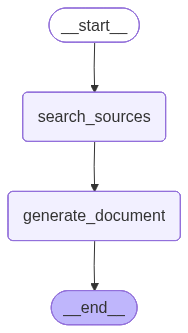

In [3]:
# Generate Document from Sources
from typing import NotRequired

import inflect
from langchain_core.output_parsers import StrOutputParser

from src.output import write_affirmations_document_markdown
from src.prompts import affirmations_generate_document_from_sources_prompt_template

inflect_engine = inflect.engine()

str_output_parser = StrOutputParser()


class GenerateDocumentFromSourcesState(SubjectState):
    document: NotRequired[str]


def generate_document(
    state: GenerateDocumentFromSourcesState,
) -> dict[str, str]:
    print(f"📄 Generating document from sources for subject: {state.get('subject').name}...")
    subject = state.get("subject")
    sources = state.get("sources")

    messages = affirmations_generate_document_from_sources_prompt_template.format_messages(
        subject_name=subject.name,
        category_name=subject.category.name,
        category_name_plural=inflect_engine.plural(subject.category.name),  # type: ignore[arg-type]
        sources=sources,
    )

    document = str_output_parser.invoke(llm_generative.invoke(messages))
    write_affirmations_document_markdown(subject, document)

    return {"document": document}


graph_builder = StateGraph(GenerateDocumentFromSourcesState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_node("generate_document", generate_document)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", "generate_document")
graph_builder.add_edge("generate_document", END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

# state = graph.invoke({"subject": TAROT_CARDS[0]})
# print(state)

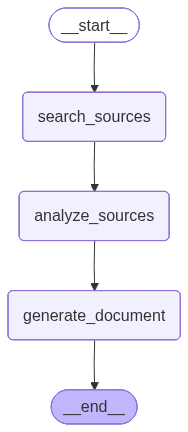

In [4]:
# Generate Document from Source Analysis
from typing import NotRequired

import inflect
from langchain_core.output_parsers import StrOutputParser

from src.prompts import (
    affirmations_analyze_sources_prompt_template,
    affirmations_generate_document_prompt_template,
)

inflect_engine = inflect.engine()

str_output_parser = StrOutputParser()


class GenerateDocumentFromAnalysisState(GenerateDocumentFromSourcesState):
    source_analysis: NotRequired[str]


def analyze_sources(state: GenerateDocumentFromAnalysisState) -> dict[str, str]:
    print(f"💭 Analyzing sources for subject: {state.get('subject').name}")
    subject = state.get("subject")
    messages = affirmations_analyze_sources_prompt_template.format_messages(
        subject_name=subject.name,
        category_name=subject.category.name,
        sources=state.get("sources"),
    )
    source_analysis = str_output_parser.invoke(llm_analytical.invoke(messages))
    return {"source_analysis": source_analysis}


def generate_document(state: GenerateDocumentFromAnalysisState) -> dict[str, str]:
    print(f"📄 Generating document from source analysis of subject: {state.get('subject').name}...")
    subject = state.get("subject")
    messages = affirmations_generate_document_prompt_template.format_messages(
        subject_name=subject.name,
        category_name=subject.category.name,
        category_name_plural=inflect_engine.plural(subject.category.name),  # type: ignore[arg-type]
        source_analysis=state.get("source_analysis", ""),
    )
    document = str_output_parser.invoke(llm_generative.invoke(messages))
    write_affirmations_document_markdown(subject, document)
    return {"document": document}


graph_builder = StateGraph(GenerateDocumentFromAnalysisState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_node("analyze_sources", analyze_sources)
graph_builder.add_node("generate_document", generate_document)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", "analyze_sources")
graph_builder.add_edge("analyze_sources", "generate_document")
graph_builder.add_edge("generate_document", END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

# state = graph.invoke({"subject": TAROT_CARDS[0]})
# pprint(state)

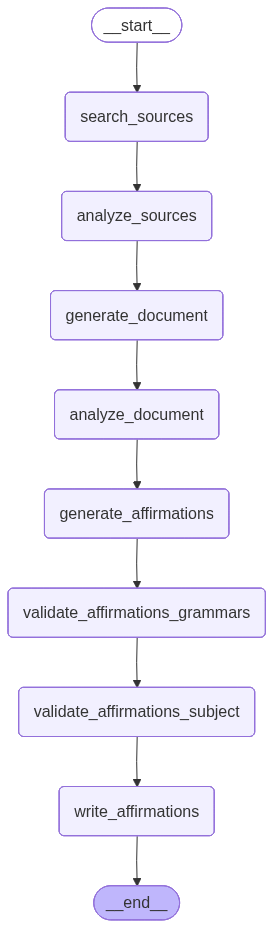

🔍 Searching sources for subject: Man...
⚠️ Warning: No text extracted from URL: https://medium.com/@bookofshadowsprint/the-man-lenormand-card-masculine-influence-actions-and-perspectives-01165f806826
💭 Analyzing sources for subject: Man
🪙 Tokens input: 4096, Tokens output: 583, Tokens total: 4679
📄 Generating document from source analysis of subject: Man...
🪙 Tokens input: 884, Tokens output: 11501, Tokens total: 12385
💾 Wrote affirmations document Markdown to: output/affirmations/documents/lenormand/28-man.md
💭 Analyzing document for subject: Man...
🪙 Tokens input: 4096, Tokens output: 223, Tokens total: 4319
🔮 Generating affirmations for subject: Man...
🔮 Generating affirmations for grammar: ✅ Finite Indicative Active Past Simple First Singular...
🪙 Tokens input: 715, Tokens output: 59, Tokens total: 774
🔮 Generating affirmations for grammar: ⭐ Finite Indicative Active Present Simple First Singular...
🪙 Tokens input: 716, Tokens output: 57, Tokens total: 773
🔮 Generating affirmations

In [5]:
# Generate Affirmations
import operator
from typing import Annotated, NotRequired, TypeVar, cast

import inflect
import json5 as _json5
from langchain_core.exceptions import OutputParserException
from langchain_core.messages import BaseMessage
from langchain_core.output_parsers import BaseOutputParser, StrOutputParser
from langchain_core.runnables import Runnable
from pydantic import BaseModel as PydanticBaseModel

from src.grammars import GRAMMARS, Grammar
from src.models import (
    Affirmation,
    GeneratedAffirmations,
    GrammarAffirmations,
    SubjectAffirmations,
    ValidationResult,
)
from src.output import write_affirmations_json, write_affirmations_markdown
from src.prompts import (
    affirmations_analyze_document_prompt_template,
    affirmations_generate_affirmations_prompt_template,
    affirmations_validate_affirmation_prompt_template,
    affirmations_validate_affirmation_subject_prompt_template,
)
from src.subjects import LENORMAND_CARDS

inflect_engine = inflect.engine()
str_output_parser = StrOutputParser()

MAX_RETRIES = 3

_T = TypeVar("_T")


class Json5PydanticOutputParser(BaseOutputParser[PydanticBaseModel]):
    """Output parser using json5 to handle lenient JSON (e.g. trailing commas)."""

    pydantic_object: type[PydanticBaseModel]

    def parse(self, text: str) -> PydanticBaseModel:
        try:
            data = _json5.loads(text)
            return self.pydantic_object.model_validate(data)
        except Exception as e:
            raise OutputParserException(f"Invalid json output: {text}") from e

    @property
    def _type(self) -> str:
        return "json5_pydantic"


def invoke_with_retry(
    chain: Runnable[list[BaseMessage], _T],
    messages: list[BaseMessage],
    max_retries: int = MAX_RETRIES,
) -> _T:
    """Invoke a LangChain chain with retry on transient failures."""
    for attempt in range(max_retries + 1):
        try:
            return chain.invoke(messages)
        except Exception as e:
            if attempt == max_retries:
                raise
            print(f"⚠️ Attempt {attempt + 1} failed: {e}. Retrying...")
    raise AssertionError("unreachable")


class GenerateAffirmationsState(GenerateDocumentFromAnalysisState):
    document_analysis: NotRequired[str]
    grammars: list[Grammar]
    grammar_affirmations: NotRequired[list[GrammarAffirmations]]
    validation_failures: NotRequired[Annotated[list[str], operator.add]]


def analyze_document(state: GenerateAffirmationsState) -> dict[str, str]:
    print(f"💭 Analyzing document for subject: {state.get('subject').name}...")
    messages = affirmations_analyze_document_prompt_template.format_messages(
        subject_name=state.get("subject").name,
        category_name=state.get("subject").category.name,
        document=state.get("document", ""),
    )
    return {"document_analysis": str_output_parser.invoke(llm_analytical.invoke(messages))}


def generate_affirmations(
    state: GenerateAffirmationsState,
) -> dict[str, list[GrammarAffirmations]]:
    print(f"🔮 Generating affirmations for subject: {state.get('subject').name}...")

    chain = llm_creative.bind(
        format=GeneratedAffirmations.model_json_schema()
    ) | Json5PydanticOutputParser(pydantic_object=GeneratedAffirmations)
    grammar_affirmations: list[GrammarAffirmations] = []

    for grammar in state.get("grammars", []):
        print(f"🔮 Generating affirmations for grammar: {grammar.name}...")
        messages = affirmations_generate_affirmations_prompt_template.format_messages(
            subject_name=state.get("subject").name,
            document_analysis=state.get("document_analysis", ""),
            grammar_name=grammar.name,
            grammar_description=grammar.description,
            grammar_specifier_descriptions=grammar.specifier_descriptions,
            grammar_specifiers=", ".join(grammar.specifiers),
            grammar_examples="; ".join(grammar.examples),
            grammar_emoji=grammar.emoji,
        )
        try:
            generated = cast("GeneratedAffirmations", invoke_with_retry(chain, messages))
        except Exception as e:
            print(
                f"❌ Failed to generate affirmations for grammar '{grammar.name}' "
                f"after {MAX_RETRIES} retries: {e}. Skipping."
            )
            continue
        affirmations = [Affirmation(text=text) for text in generated.affirmations]
        grammar_affirmations.append(GrammarAffirmations(grammar=grammar, affirmations=affirmations))

    return {"grammar_affirmations": grammar_affirmations}


def validate_affirmations_grammars(
    state: GenerateAffirmationsState,
) -> dict[str, list[str]]:
    print(f"✅ Validating affirmations grammar for subject: {state.get('subject').name}...")

    chain = llm_validator.bind(
        format=ValidationResult.model_json_schema()
    ) | Json5PydanticOutputParser(pydantic_object=ValidationResult)
    failures: list[str] = []

    for grammar_affirmations in state.get("grammar_affirmations", []):
        grammar = grammar_affirmations.grammar
        print(f"✅ Validating affirmations grammar for grammar: {grammar.name}...")

        for affirmation in grammar_affirmations.affirmations:
            print(f"✅ Validating affirmation grammar: '{affirmation.text}'...")
            messages = affirmations_validate_affirmation_prompt_template.format_messages(
                affirmation_text=affirmation.text,
                grammar_name=grammar.name,
                grammar_description=grammar.description,
                grammar_specifiers=", ".join(grammar.specifiers),
                grammar_specifier_descriptions=grammar.specifier_descriptions,
                grammar_examples="; ".join(grammar.examples),
            )
            try:
                result = cast("ValidationResult", invoke_with_retry(chain, messages))
            except Exception as e:
                print(f"❌ Parse error validating '{affirmation.text}', skipping: {e}")
                continue

            if not result.valid:
                failure = f"[{grammar.name}] '{affirmation.text}': {result.reason}"
                failures.append(failure)
                print(f"❌ Grammar Validation failure: {failure}")

    if not failures:
        print("✅ Grammar Validation: all affirmations passed.")
    else:
        print(f"❌ Grammar Validation: {len(failures)} failure(s) logged.")

    return {"validation_failures": failures}


def validate_affirmations_subject(
    state: GenerateAffirmationsState,
) -> dict[str, list[str]]:
    subject = state.get("subject")
    print(f"✅ Validating affirmations subject for subject: {subject.name}...")

    chain = llm_validator.bind(
        format=ValidationResult.model_json_schema()
    ) | Json5PydanticOutputParser(pydantic_object=ValidationResult)
    failures: list[str] = []

    for grammar_affirmations in state.get("grammar_affirmations", []):
        grammar = grammar_affirmations.grammar

        for affirmation in grammar_affirmations.affirmations:
            print(f"✅ Validating affirmation subject: '{affirmation.text}'...")
            messages = affirmations_validate_affirmation_subject_prompt_template.format_messages(
                affirmation_text=affirmation.text,
                subject_name=subject.name,
                category_name=subject.category.name,
                document=state.get("document", ""),
            )
            try:
                result = cast("ValidationResult", invoke_with_retry(chain, messages))
            except Exception as e:
                print(f"❌ Parse error validating '{affirmation.text}', skipping: {e}")
                continue

            if not result.valid:
                failure = f"[{grammar.name}] '{affirmation.text}': {result.reason}"
                failures.append(failure)
                print(f"❌ Subject Validation failure: {failure}")

    if not failures:
        print("✅ Subject Validation: all affirmations passed.")
    else:
        print(f"❌ Subject Validation: {len(failures)} failure(s) logged.")

    return {"validation_failures": failures}


def write_affirmations(state: GenerateAffirmationsState) -> GenerateAffirmationsState:
    subject_affirmations = SubjectAffirmations(
        subject=state.get("subject"),
        grammars=state.get("grammar_affirmations", []),
    )
    write_affirmations_json(subject_affirmations)
    write_affirmations_markdown(subject_affirmations)
    return state


graph_builder = StateGraph(GenerateAffirmationsState)
graph_builder.add_node("search_sources", search_sources)
graph_builder.add_node("analyze_sources", analyze_sources)
graph_builder.add_node("generate_document", generate_document)
graph_builder.add_node("analyze_document", analyze_document)
graph_builder.add_node("generate_affirmations", generate_affirmations)
graph_builder.add_node("validate_affirmations_grammars", validate_affirmations_grammars)
graph_builder.add_node("validate_affirmations_subject", validate_affirmations_subject)
graph_builder.add_node("write_affirmations", write_affirmations)
graph_builder.add_edge(START, "search_sources")
graph_builder.add_edge("search_sources", "analyze_sources")
graph_builder.add_edge("analyze_sources", "generate_document")
graph_builder.add_edge("generate_document", "analyze_document")
graph_builder.add_edge("analyze_document", "generate_affirmations")
graph_builder.add_edge("generate_affirmations", "validate_affirmations_grammars")
graph_builder.add_edge("validate_affirmations_grammars", "validate_affirmations_subject")
graph_builder.add_edge("validate_affirmations_subject", "write_affirmations")
graph_builder.add_edge("write_affirmations", END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


for subject in LENORMAND_CARDS[27:]:
    state = graph.invoke({"subject": subject, "grammars": GRAMMARS})

    print("\n=== SOURCE ANALYSIS ===")
    print(state.get("source_analysis"))

    print("\n=== DOCUMENT ===")
    print(state.get("document", ""))

    print("\n=== DOCUMENT ANALYSIS ===")
    print(state.get("document_analysis"))

    print("\n=== GENERATED AFFIRMATIONS ===")
    for grammar_affirmation in state.get("grammar_affirmations", []):
        print(f"\n{grammar_affirmation.grammar.name}:")
        for affirmation in grammar_affirmation.affirmations:
            print(f"  - {affirmation.text}")

    print("\n=== VALIDATION FAILURES ===")
    for failure in state.get("validation_failures", []):
        print(f"  {failure}")
    if not state.get("validation_failures"):
        print("  None")